# Load CSVs

In [1]:
import pandas as pd

In [2]:
inflation = pd.read_csv("inflation_clean.csv")
interest = pd.read_csv("interest_clean.csv")

# Inspect each dataset
## Double check they are standardize

In [3]:
print(inflation.columns)

Index(['date', 'country', 'inflation'], dtype='object')


In [4]:
print(interest.columns)

Index(['date', 'interest'], dtype='object')


In [5]:
print(inflation.duplicated(["date", "country"]).sum())

0


In [6]:
print(interest.duplicated(["date"]).sum())

0


## Convert interest in continuous monthly data (now it jumps in months where we dont have data)

In [7]:
interest["date"] = pd.to_datetime(interest["date"], errors="coerce")
interest["interest"] = pd.to_numeric(interest["interest"], errors="coerce")
interest = interest.groupby("date", as_index=False)["interest"].mean()

In [8]:
#Fill up each month for the inflation range

full_months = pd.date_range(
    start=inflation["date"].min(),
    end=inflation["date"].max(),
    freq="MS"   # Month Start
)

In [9]:
interest_monthly = (
    interest.set_index("date")
    .reindex(full_months)
    .rename_axis("date")
    .reset_index()
)

interest_monthly["interest"] = interest_monthly["interest"].ffill().bfill()

In [10]:
print(interest_monthly.head(15))

         date  interest
0  2015-01-01      -0.3
1  2015-02-01      -0.3
2  2015-03-01      -0.3
3  2015-04-01      -0.3
4  2015-05-01      -0.3
5  2015-06-01      -0.3
6  2015-07-01      -0.3
7  2015-08-01      -0.3
8  2015-09-01      -0.3
9  2015-10-01      -0.3
10 2015-11-01      -0.3
11 2015-12-01      -0.3
12 2016-01-01      -0.3
13 2016-02-01      -0.3
14 2016-03-01      -0.4


In [11]:
print(interest_monthly.tail())

          date  interest
103 2023-08-01      3.75
104 2023-09-01      4.00
105 2023-10-01      4.00
106 2023-11-01      4.00
107 2023-12-01      4.00


In [12]:
print(interest_monthly.isna().sum())

date        0
interest    0
dtype: int64


### ECB interest rate data records policy change dates rather than a complete monthly series. 

To align it with monthly inflation data, we expanded the series to a monthly frequency and forward-filled values, assuming the policy rate remained constant until the next recorded change.

In [13]:
interest_monthly["interest"] = interest_monthly["interest"].ffill().bfill()

## Merge

In [14]:
inflation["date"] = pd.to_datetime(inflation["date"], errors="coerce")
interest_monthly["date"] = pd.to_datetime(interest_monthly["date"], errors="coerce")

In [15]:
df = inflation.merge(
    interest_monthly,
    on = "date",
    how = "left"
)

In [16]:
df.head()

,date,country,inflation,interest
0,2015-01-01,DE,-0.5,-0.3
1,2015-02-01,DE,-0.2,-0.3
2,2015-03-01,DE,0.3,-0.3
3,2015-04-01,DE,1.0,-0.3
4,2015-05-01,DE,1.6,-0.3


In [17]:
df.columns

Index(['date', 'country', 'inflation', 'interest'], dtype='object')

In [18]:
df.shape

(432, 4)

In [19]:
inflation.duplicated(["date", "country"]).sum()

np.int64(0)

# Merge all (Interest & Inflation) with the energy index

In [20]:
energy_index = pd.read_csv("energy_clean_index.csv")

In [21]:
print("\nEnergy")
print(energy_index.head())
print(energy_index.columns.tolist())
print(energy_index.shape)


Energy
         date country  energy_price_index
0  2015-01-01      DE               100.5
1  2015-02-01      DE               101.9
2  2015-03-01      DE               101.9
3  2015-04-01      DE               101.5
4  2015-05-01      DE               101.8
['date', 'country', 'energy_price_index']
(432, 3)


In [22]:
energy_index["date"] = pd.to_datetime(energy_index["date"], errors="coerce")
energy_index["country"] = energy_index["country"].astype(str).str.strip().str.upper()

In [23]:
print("Merged base dates:", df["date"].min(), df["date"].max())
print("Energy dates:", energy_index["date"].min(), energy_index["date"].max())

print("Merged base countries:", sorted(df["country"].unique()))
print("Energy countries:", sorted(energy_index["country"].unique()))

Merged base dates: 2015-01-01 00:00:00 2023-12-01 00:00:00
Energy dates: 2015-01-01 00:00:00 2023-12-01 00:00:00
Merged base countries: ['DE', 'ES', 'FR', 'IT']
Energy countries: ['DE', 'ES', 'FR', 'IT']


In [24]:
print("Merged base duplicates:", df.duplicated(subset=["date", "country"]).sum())
print("Energy duplicates:", energy_index.duplicated(subset=["date", "country"]).sum())

Merged base duplicates: 0
Energy duplicates: 0


In [25]:
df_final = df.merge(
    energy_index,
    on=["date", "country"],
    how="left"
)

In [26]:
df_final.head()

,date,country,inflation,interest,energy_price_index
0,2015-01-01,DE,-0.5,-0.3,100.5
1,2015-02-01,DE,-0.2,-0.3,101.9
2,2015-03-01,DE,0.3,-0.3,101.9
3,2015-04-01,DE,1.0,-0.3,101.5
4,2015-05-01,DE,1.6,-0.3,101.8


In [27]:
print(df_final.columns.tolist())

['date', 'country', 'inflation', 'interest', 'energy_price_index']


In [28]:
print(df_final.shape)

(432, 5)


In [29]:
print(df_final.isna().sum())
print("Final duplicates:", df_final.duplicated(subset=["date", "country"]).sum())

date                  0
country               0
inflation             0
interest              0
energy_price_index    0
dtype: int64
Final duplicates: 0


In [30]:
print(df_final.groupby(["date", "country"]).size().value_counts())

1    432
Name: count, dtype: int64


# Merge all (Inflation, Interest & Energy price index) with Energy rate of change

# Final data analysis

## Inflation distribution by country

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

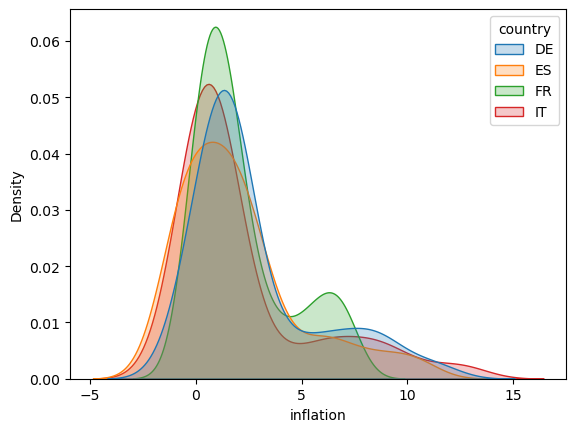

In [34]:
sns.kdeplot(data=df_final, x="inflation", hue="country", fill=True)
plt.show()

In [35]:
import numpy as np

## Interest rate distribution

<Axes: xlabel='interest', ylabel='Count'>

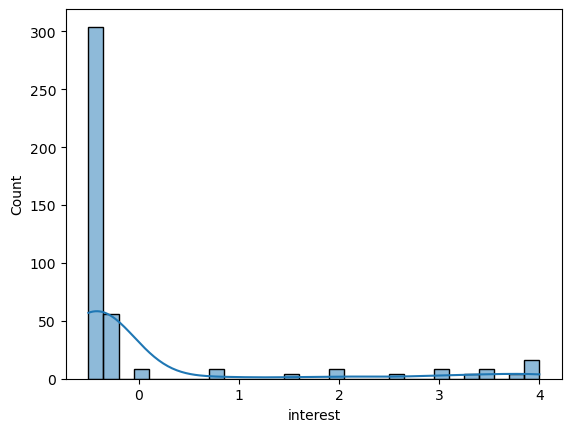

In [37]:
sns.histplot(df_final["interest"], bins=30, kde=True)